# documentation

Since you are using `StandardScaler` in your code, the **physical units** (Kelvin, Optical Depth, etc.) are converted into **"Standard Deviations"** before the kernel sees them.

This means we don't set the kernel size to "10 Kelvin" or "5 COD". Instead, we set it based on **how sensitive the output is to 1 Standard Deviation of change.**

Here is the logic and the tuned code.

### The Logic: Mapping Physics to "Length Scale"

Remember: **Small Length Scale = High Sensitivity (Curve changes fast).**

1.  **COD (Range 0-50):**

      * **Physics:** This is the strongest driver. A change of just 5-10 COD units causes a massive jump in reflection.
      * **Scaled Space:** Since the Standard Deviation of COD is roughly \~15, a change of 5 units is about `0.3` standard deviations.
      * **Setting:** We need a **very small length scale** (`0.3` to `0.5`) so the model can react fast to cloud changes.

2.  **Ta (Range 233-303 K):**

      * **Physics:** Temperature affects the atmosphere slowly. A change of 10K usually results in a small, smooth change in radiation (linear trend).
      * **Scaled Space:** We don't want the model to "wiggle" for every 1-2 degrees. We want it to see the big picture.
      * **Setting:** We use a **large length scale** (`2.0` to `4.0`) to force a smooth relationship.

3.  **rh (Range 0-1):**

      * **Physics:** Weakest correlation.
      * **Setting:** **Very large length scale** (`3.0`+) to prevent the model from overfitting to noise.

4.  **th0 (Range 0.5-1.0):**

      * **Physics:** The sun angle has a strong, consistent geometric effect (cosine law).
      * **Setting:** **Medium length scale** (`1.0` to `1.5`).

# start

In [15]:
import h5py
import pandas as pd
h5_file_path = "./LUT/SWRTM_case2_54layers_dnu=3_AOD=0.1243.h5"
csv_file_path = "./LUT/SWRTM_case2_54layers_dnu=3_AOD=0.1243.csv"
with h5py.File(h5_file_path, 'r') as h5_file:
    columns = [col.decode('utf-8') for col in h5_file['data/axis0'][:]]
    data = h5_file['data/block0_values'][:]
df = pd.DataFrame(data, columns=columns)
df = df[df['Ta'] >= 233]
df.to_csv(csv_file_path, index=False, encoding='utf-8')

In [ ]:
import h5py
import pandas as pd
h5_file_path = "./LUT/SWRTM_case2_54layers_dnu=3_AOD=0.1243_yuyingCases2400.h5"
csv_file_path = "./LUT/SWRTM_case2_54layers_dnu=3_AOD=0.1243_yuyingCases2400.csv"
with h5py.File(h5_file_path, 'r') as h5_file:
    columns = [col.decode('utf-8') for col in h5_file['data/axis0'][:]]
    data = h5_file['data/block0_values'][:]
df = pd.DataFrame(data, columns=columns)
df = df[df['Ta'] >= 233]
df.to_csv(csv_file_path, index=False, encoding='utf-8')

Data split 7:3 training dataset: testing dataset

In [17]:
import pandas as pd
from sklearn.model_selection import train_test_split
csv_file_path = "./LUT/SWRTM_case2_54layers_dnu=3_AOD=0.1243.csv"
df = pd.read_csv(csv_file_path)
train_df, test_df = train_test_split(df, test_size=0.3, random_state=42)
train_file_path = "./LUT/SWRTM_train.csv"
test_file_path = "./LUT/SWRTM_test.csv"
train_df.to_csv(train_file_path, index=False)  
test_df.to_csv(test_file_path, index=False)  


Correlation analysis

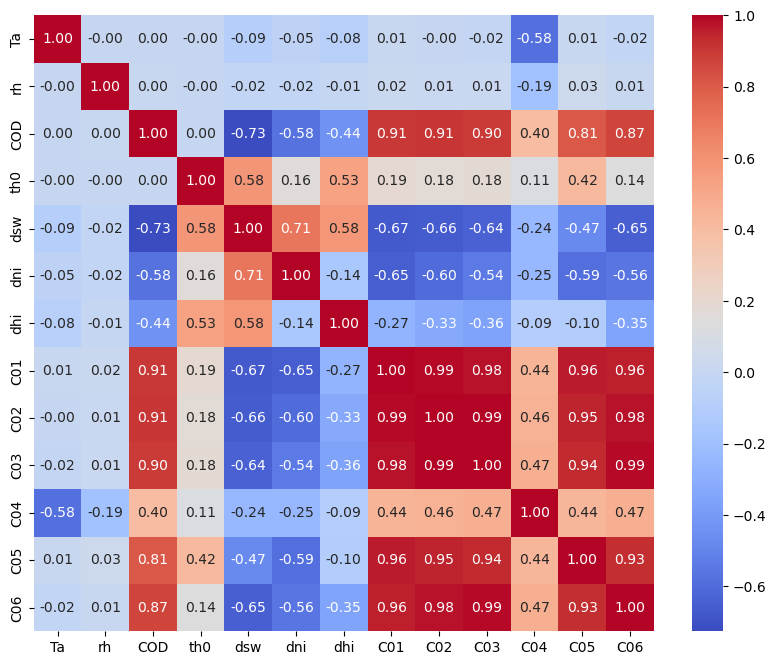

In [32]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
csv_file_path = "./LUT/SWRTM_case2_54layers_dnu=3_AOD=0.1243.csv"
df = pd.read_csv(csv_file_path)
df['th0'] = np.cos(np.radians(df['th0'])) 
correlation_matrix = df.corr()
#print(correlation_matrix)
plt.figure(figsize=(10, 8)) 
sns.heatmap(correlation_matrix, 
            annot=True,     
            fmt=".2f",      
            cmap="coolwarm", 
            cbar=True)        
plt.show()

# Gaussian Process Regression fitting using sklearn GPR model

A flexible, classical machine learning method that makes predictions based on observed patterns in your data and gives you both a predicted COD and an estimate of confidence or uncertainty for every prediction.

It tries to fit a smooth function through your data, using a mathematical structure (“kernel”) that describes how points relate to one another.

Key feature: 

- Very good for moderate-sized datasets
- Provides uncertainty estimates 

In [38]:
data.describe()

,Ta,rh,COD,th0,dsw,dni,dhi,C01,C02,C03,C04,C05,C06
count,8884.000000,8884.000000,8884.000000,8884.000000,8884.000000,8884.000000,8884.000000,8884.000000,8884.000000,8884.000000,8884.000000,8884.000000,8884.000000
mean,268.118190,0.551092,10.723855,0.810698,586.400618,242.192495,381.293081,0.225565,0.168856,0.185459,0.024500,0.254657,0.090409
std,21.660303,0.285154,15.079832,0.183488,313.317128,282.826529,201.480778,0.177157,0.180135,0.205417,0.045349,0.106684,0.089557
min,233.000000,0.100000,0.000000,0.500000,57.174321,0.013968,56.427641,0.067992,0.024729,0.029754,0.000082,0.100540,0.015847
25%,248.000000,0.300000,0.400000,0.707107,304.844230,4.802576,227.535266,0.087945,0.041420,0.054117,0.000499,0.182101,0.031493
50%,268.000000,0.600000,2.510000,0.866025,588.546580,62.497395,324.881531,0.135552,0.068601,0.063797,0.004244,0.211329,0.036565
75%,288.000000,0.800000,15.000000,0.965926,887.086707,489.969160,507.473134,0.332675,0.289836,0.336417,0.028577,0.313492,0.176904
max,303.000000,1.000000,50.000000,1.000000,1131.382839,908.668440,924.278193,0.695546,0.616433,0.691367,0.325516,0.491907,0.263065


# PCA and GPR model fitting


PCA to keep the spectral feature between 6 channels.

In [51]:
import numpy as np
import pandas as pd
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel as C
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# ... (Load your data as before) ...
file_path = "./LUT/SWRTM_train.csv"
data = pd.read_csv(file_path)

# print(f"Original Data Size: {len(data)}")
# if len(data_load) > 1500:
#     data = data_load.sample(n=1500, random_state=42).reset_index(drop=True)
#     print(">> Subsampled to 1500 rows for rapid testing.")
# else:
#     data = data_load


# process
data['th0'] = np.cos(np.radians(data['th0'])) 
F_dw_os_srf_channel = [100.56360014402173,293.8703639771758,146.06104052297425,
                           12.06884597258561,13.936208329862962,18.20438461023419]
channels = ['C01', 'C02', 'C03', 'C04', 'C05', 'C06']
data[channels] = data[channels].div(F_dw_os_srf_channel)

X = data[['Ta', 'rh', 'th0', 'COD']].values
y = data[['C01', 'C02', 'C03', 'C04', 'C05', 'C06']].values

# Scale inputs X
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X)

# Scale targets y (Important before PCA)
scaler_y = StandardScaler()
y_scaled = scaler_y.fit_transform(y)

# Apply PCA to keep the channels "fixed" together
# n_components=0.999 means "Keep enough components to explain 99.9% of the variance"
# Usually for 6 RTM channels, this might just be 2 or 3 components.
pca = PCA(n_components=0.9999)   # C04 control rh and Ta. C01~C06 control COD. 
y_pca = pca.fit_transform(y_scaled)

print(f"Original y shape: {y.shape}")   # (N, 6)
print(f"PCA y shape: {y_pca.shape}")     # (N, 3) <- Probably reduced to 3 columns
print(f"Explained Variance: {pca.explained_variance_ratio_}")

# --- STEP 2: TRAIN GPR ON THE COMPRESSED VECTOR ---

# 1. Kernel for the PCA components
initial_scales = [3.0, 3.0, 1.5, 0.35]
# ['Ta', 'rh', 'th0', 'COD']
# 1. Input Sensitivities (Length Scales) based on Heatmap
# Ta (Input 0): Impact is specific to C04, low elsewhere. 
#     -> Start HIGH (3.0) so it doesn't add noise to C01-C03.
# rh (Input 1): Similar to Ta. 
#     -> Start HIGH (3.0).
# th0 (Input 2): Moderate impact on C05 (0.42) and others.
#     -> Start MEDIUM (1.5).
# COD (Input 3): MASSIVE impact (0.91) on almost everything. 
#     -> Start LOW (0.5) so the model can react quickly to cloud changes.


# We allow COD to go very small (1e-2) because cloud physics is sharp.
# We force Ta/rh to stay above 0.1 so they don't cause overfitting.
# --- 2. Length Scale Bounds (The "Safety Limits") ---
# We define distinct limits for each variable.
# Format: (Lower_Limit, Upper_Limit)
bounds = [
    (0.5, 10.0),  # Ta: Don't let it get too wiggly (<0.5), allow it to be linear (>5)
    (0.5, 10.0),  # rh: Same as Ta
    (0.1, 8.0),   # th0: Standard geometric range
    (0.05, 2.0)   # COD: ALLOW it to be very sharp (0.05), prevent it from being lazy (>2.0)
]

# --- 3. Construct the Kernel ---
# RTM data is clean. WhiteKernel is small.
kernel = C(1.0, (1e-2, 1e3)) * \
         RBF(length_scale=initial_scales, length_scale_bounds=bounds) + \
         WhiteKernel(noise_level=1e-5, noise_level_bounds=(1e-6, 1e-3))

# Train on y_pca, not the raw y
gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=0, random_state=42)


gpr.fit(X_scaled, y_pca)

Original y shape: (8884, 6)
PCA y shape: (8884, 5)
Explained Variance: [0.85301103 0.12512588 0.01472289 0.00591542 0.00122096]


,kernel,1**2 * RBF(le...e_level=1e-05)
,alpha,1e-10
,optimizer,'fmin_l_bfgs_b'
,n_restarts_optimizer,0
,normalize_y,False
,copy_X_train,True
,n_targets,None
,random_state,42
,kernel__k1,"1**2 * RBF(le...3, 1.5, 0.35])"
,kernel__k2,WhiteKernel(noise_level=1e-05)
,kernel__k1__k1,1**2


In [53]:
# WRONG (Shows what you told it to do)
print(gpr.kernel) 

# CORRECT (Shows what it learned)
print(gpr.kernel_)

1**2 * RBF(length_scale=[3, 3, 1.5, 0.35]) + WhiteKernel(noise_level=1e-05)
2.68**2 * RBF(length_scale=[1.86, 1.92, 6.79, 0.304]) + WhiteKernel(noise_level=4.22e-05)


=== Model Evaluation Metrics ===
         RMSE (Abs)  MAE (Abs)  rRMSE (%)  R2 Score
C01          0.0006     0.0005     0.5202    1.0000
C02          0.0007     0.0005     0.9375    1.0000
C03          0.0005     0.0004     0.6249    1.0000
C04          0.0005     0.0003    19.4050    0.9999
C05          0.0009     0.0007     0.4853    0.9999
C06          0.0003     0.0002     0.6208    1.0000
AVERAGE      0.0006     0.0004     3.7656    1.0000


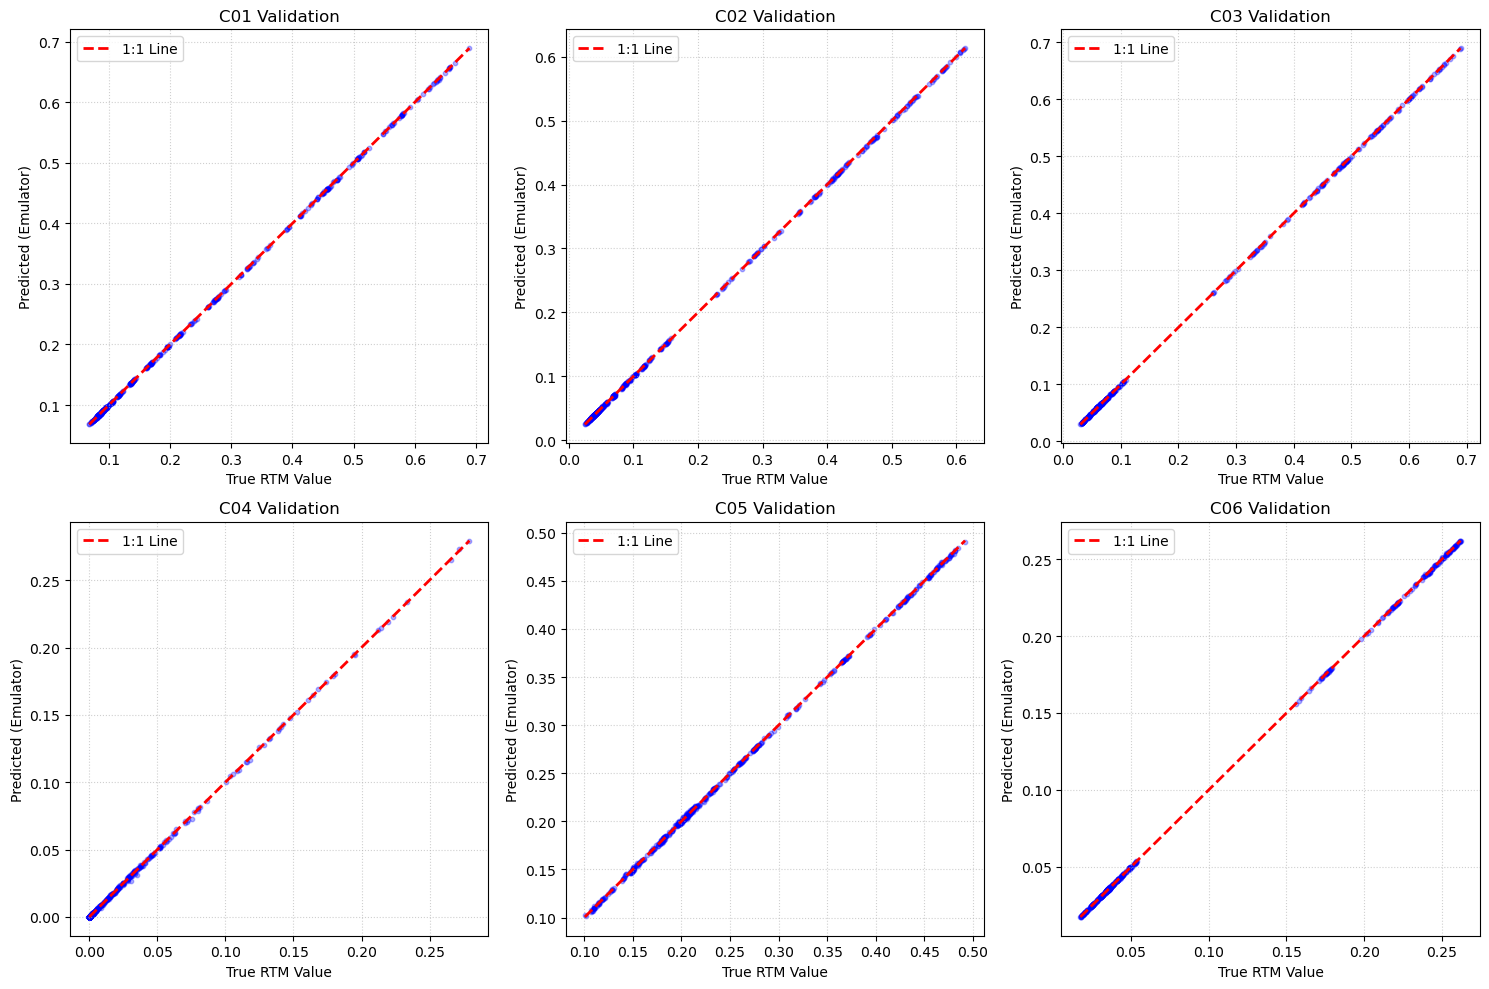

In [55]:
def predict_spectrum(new_X_raw):
    """
    Input: Array of shape (N, 4) -> [Ta, rh, th0, COD]
    Output: Array of shape (N, 6) -> [C01 ... C06]
    """
    # A. Scale Input (Using the loaded scaler)
    X_new_scaled = scaler_X.transform(new_X_raw)
    
    # B. Predict PCA components (Using the loaded GPR)
    y_pred_pca = gpr.predict(X_new_scaled)
    
    # C. Inverse PCA (Reconstruct the 6 channels)
    y_pred_scaled = pca.inverse_transform(y_pred_pca)
    
    # D. Inverse Scale (Get back to physical units)
    y_pred_final = scaler_y.inverse_transform(y_pred_scaled)

    y_pred_final = np.clip(y_pred_final, 0.0, 1.0)
    
    return y_pred_final
# Test with the first 5 rows of training data
test_prediction = predict_spectrum(X[:500])
metrics = evaluate_rtm_performance(y[:500], test_prediction, channels)

# 2. See the plots
plot_scatter_validation(y[:500], test_prediction, channels)

### Model save

In [56]:
import joblib
import os

# 1. Create a dictionary containing all components
model_bundle = {
    'scaler_X': scaler_X,
    'scaler_y': scaler_y,
    'pca': pca,
    'gpr_model': gpr,
    'metadata': {
        'description': 'SWRTM Emulator with PCA+GPR',
        'date': '2025-11-20',
        'input_columns': ['Ta', 'rh', 'th0', 'COD'],
        'output_channels': ['C01', 'C02', 'C03', 'C04', 'C05', 'C06']
    }
}

# 2. Define save path
save_dir = "./GUI/"
if not os.path.exists(save_dir):
    os.makedirs(save_dir)
    
save_path = os.path.join(save_dir, "SWRTM_PCA_GPR_v1.pkl")

# 3. Save to disk
joblib.dump(model_bundle, save_path)

print(f"Model pipeline successfully saved to: {save_path}")

Model pipeline successfully saved to: ./GUI/SWRTM_PCA_GPR_v1.pkl


# results validation

### model loading

In [59]:
import joblib
import numpy as np

# 1. Load the bundle
model_path = "./GUI/SWRTM_PCA_GPR_v1.pkl"
print(f"Loading model from {model_path}...")

loaded_bundle = joblib.load(model_path)

# 2. Extract the components back into variables
scaler_X = loaded_bundle['scaler_X']
scaler_y = loaded_bundle['scaler_y']
pca      = loaded_bundle['pca']
gpr      = loaded_bundle['gpr_model']

print("Model loaded successfully!")

# 3. Re-define the prediction function using these loaded objects
def predict_spectrum(new_X_raw):
    """
    Input: Array of shape (N, 4) -> [Ta, rh, th0, COD]
    Output: Array of shape (N, 6) -> [C01 ... C06]
    """
    # A. Scale Input (Using the loaded scaler)
    X_new_scaled = scaler_X.transform(new_X_raw)
    
    # B. Predict PCA components (Using the loaded GPR)
    y_pred_pca = gpr.predict(X_new_scaled)
    
    # C. Inverse PCA (Reconstruct the 6 channels)
    y_pred_scaled = pca.inverse_transform(y_pred_pca)
    
    # D. Inverse Scale (Get back to physical units)
    y_pred_final = scaler_y.inverse_transform(y_pred_scaled)

    y_pred_final = np.clip(y_pred_final, 0.0, 1.0)
    
    return y_pred_final


# --- TEST IT ---
# Example input: Ta=290K, rh=0.5, th0=0.8, COD=10
file_path = "./LUT/SWRTM_case2_54layers_dnu=3_AOD=0.1243.csv"
data_test = pd.read_csv(file_path)
data_test['th0'] = np.cos(np.radians(data_test['th0'])) 

F_dw_os_srf_channel = [100.56360014402173,293.8703639771758,146.06104052297425,
                           12.06884597258561,13.936208329862962,18.20438461023419]
channels = ['C01', 'C02', 'C03', 'C04', 'C05', 'C06']
data_test[channels] = data_test[channels].div(F_dw_os_srf_channel)

X_test = data_test[['Ta', 'rh', 'th0', 'COD']].values
y_test = data_test[['C01', 'C02', 'C03', 'C04', 'C05', 'C06']].values

y_pred = predict_spectrum(X_test)

Loading model from ./GUI/SWRTM_PCA_GPR_v1.pkl...
Model loaded successfully!


=== Model Evaluation Metrics ===
         RMSE (Abs)  MAE (Abs)  rRMSE (%)  R2 Score
C01          0.0006     0.0005     0.5293    1.0000
C02          0.0007     0.0005     0.9304    1.0000
C03          0.0005     0.0004     0.6653    1.0000
C04          0.0005     0.0003    20.5880    0.9999
C05          0.0009     0.0007     0.4991    0.9999
C06          0.0003     0.0002     0.6518    1.0000
AVERAGE      0.0006     0.0004     3.9773    1.0000


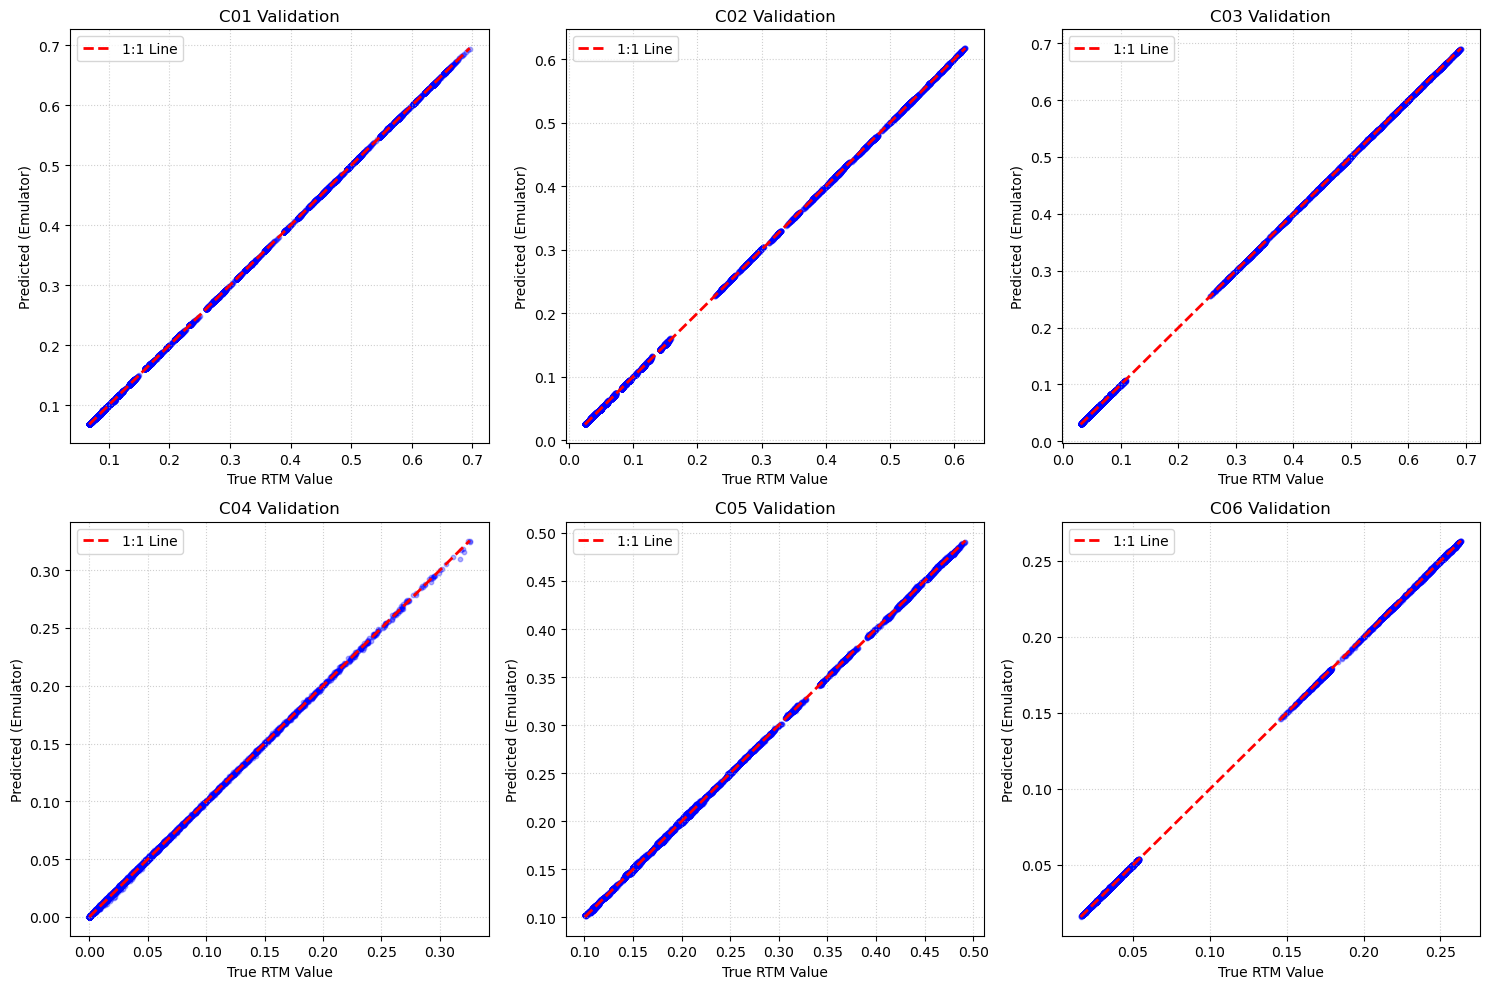

In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

def evaluate_rtm_performance(y_test, y_pred, channel_names=None):
    if channel_names is None:
        channel_names = [f'C{i+1:02d}' for i in range(y_test.shape[1])]
    
    # --- 1. Calculate Metrics ---
    
    # RMSE (Root Mean Squared Error) - Sensitive to large errors
    rmse_per_channel = np.sqrt(mean_squared_error(y_test, y_pred, multioutput='raw_values'))
    
    # MAE (Mean Absolute Error) - More robust to outliers
    mae_per_channel = mean_absolute_error(y_test, y_pred, multioutput='raw_values')
    
    # R2 Score - How well the trend is captured (1.0 is perfect)
    r2_per_channel = r2_score(y_test, y_pred, multioutput='raw_values')
    
    # Relative RMSE (Percentage Error)
    # We add a small epsilon (1e-6) to avoid division by zero if y_test has 0s
    # Formula: sqrt(mean(((y_pred - y_test) / y_test)^2)) * 100
    relative_errors = (y_pred - y_test) / (y_test + 1e-6)
    rrmse_per_channel = np.sqrt(np.mean(relative_errors**2, axis=0)) * 100

    # --- 2. Create a Summary Table ---
    metrics_df = pd.DataFrame({
        'RMSE (Abs)': rmse_per_channel,
        'MAE (Abs)': mae_per_channel,
        'rRMSE (%)': rrmse_per_channel,
        'R2 Score': r2_per_channel
    }, index=channel_names)
    
    # Add an "Average" row at the bottom
    metrics_df.loc['AVERAGE'] = metrics_df.mean()
    
    print("=== Model Evaluation Metrics ===")
    print(metrics_df.round(4))
    
    return metrics_df

# --- 3. Visualization Function (Crucial for RTM Papers) ---
def plot_scatter_validation(y_test, y_pred, channel_names):
    fig, axes = plt.subplots(2, 3, figsize=(15, 10)) # 2 rows, 3 columns for 6 channels
    axes = axes.ravel()
    
    for i in range(6):
        # Get data for this channel
        true = y_test[:, i]
        pred = y_pred[:, i]
        
        # Calculate nice limits
        min_val = min(true.min(), pred.min())
        max_val = max(true.max(), pred.max())
        
        ax = axes[i]
        # Scatter plot
        ax.scatter(true, pred, alpha=0.3, s=10, color='blue')
        
        # 1:1 line (Perfect prediction)
        ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='1:1 Line')
        
        ax.set_title(f"{channel_names[i]} Validation")
        ax.set_xlabel("True RTM Value")
        ax.set_ylabel("Predicted (Emulator)")
        ax.legend()
        ax.grid(True, linestyle=':', alpha=0.6)

    plt.tight_layout()
    plt.show()

# === RUN IT ===
channels = ['C01', 'C02', 'C03', 'C04', 'C05', 'C06']

# 1. Get the numbers
metrics = evaluate_rtm_performance(y_test, y_pred, channels)

# 2. See the plots
plot_scatter_validation(y_test, y_pred, channels)